In [1]:
from time import time

import jax.numpy as jnp

from quantum_simulation.jpc_chip import JpcChip
from quantum_simulation.parameters_and_constants import JPCConfig, QuantumParameters

On pose $\hbar = 1$.

**Unités :** 
- Les fréquences et l'Hamiltonien sont données en $\mathrm{MHz}$
- Le temps est donné en  $\mu \mathrm{s} $
- Les $\epsilon$ sont donnés en $ \sqrt{\mathrm{MHz}} $

Dans le référentiel tournant (*Rotating Frame*) l'Hamiltonien du système s'écrit (sans drive) :

$$ H = K_{aa} \left(a^\dagger a \right)^2 + K_{bb} \left(b^\dagger b\right)^2 - K_{ab} \left(a^\dagger a\right) \left( b^\dagger b \right) + g \left( a^\dagger b + a b^\dagger \right) + g_\text{sq} \left( a^\dagger b^\dagger + a b \right) $$

Le *drive* s'exprime dans ce même référentiel :

$$ H_\text{drive} = i \sqrt{\kappa_a}  \left( \epsilon_a^* a - \epsilon_a a^\dagger \right) + i \sqrt{\kappa_b}  \left( \epsilon_b^* b - \epsilon_b b^\dagger \right)   $$

Le *collapse operator* s'exprime :

$$ C = \sqrt{\kappa_a}\; a + \sqrt{\kappa_b}\; b \; \overset{???}{+}\; \sqrt{\kappa_\phi} \;\left( a^\dagger a + b^\dagger b \right) $$


In [2]:
X = jnp.array([-1, -0.7, 0, 0.7, 1, 0.7, 0, -0.7, 1, 1, 1, 1, -1, -1, -1, -1])
#X = jnp.array([1, 1, 1, 1, -1, -1, -1, -1])
params_G = [QuantumParameters(700, 15, 0, 0, 0, 0)]

QP_Dudas = JPCConfig(
    DIM_A=15,
    DIM_B=15,
    OMEGA_A=1e4,
    OMEGA_B=9 * 1e3,
    KAPPA_A=17,
    KAPPA_B=21,
    K_AA=0.1,
    K_BB=0.1,
    K_AB=0.05,
    EPSILON_A=130,
    EPSILON_B=130,
    DRIVE_DURATION=0.04,
    MEASURE_RESOLUTION=10,
    SIMULATION_RESOLUTION=10
)

QP = QP_Dudas


chip = JpcChip(QP)



In [3]:
t1 = time()
A = chip.run_simulation(X, params_G)
print(time() - t1)

#c-profile

|██████████| 100.0% ◆ elapsed 01m44s ◆ remaining 0.00ms  


113.47446084022522


C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\ozher\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


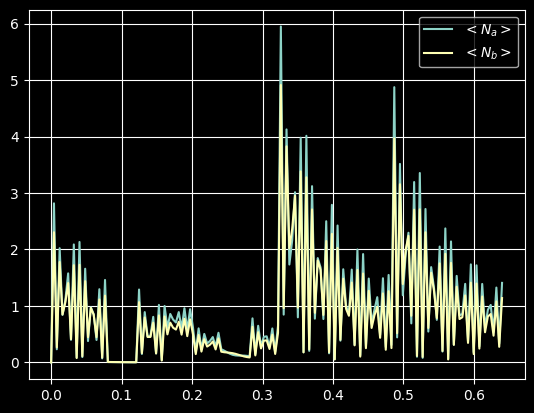

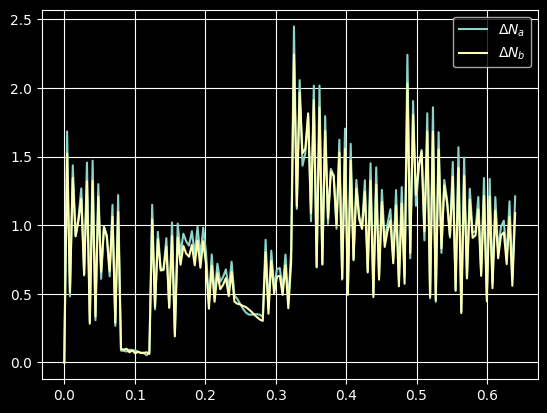

In [4]:
l = A[0].photon_distribution.Plot_Mean_Photon_Number()
l = A[0].photon_distribution.Plot_Sigma_Photon_Number()

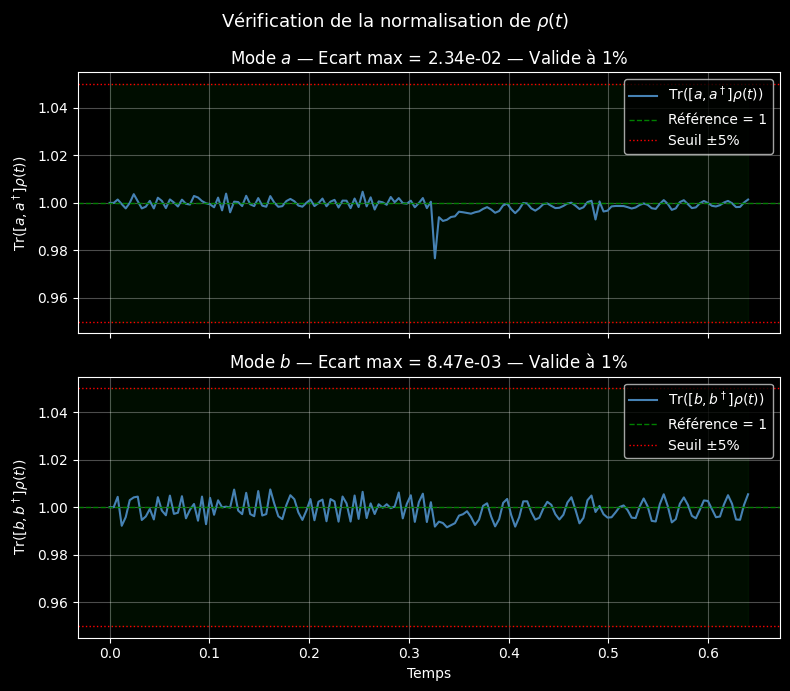

In [5]:
Tr_a, TR_b = A[0].plot_trace_verification()

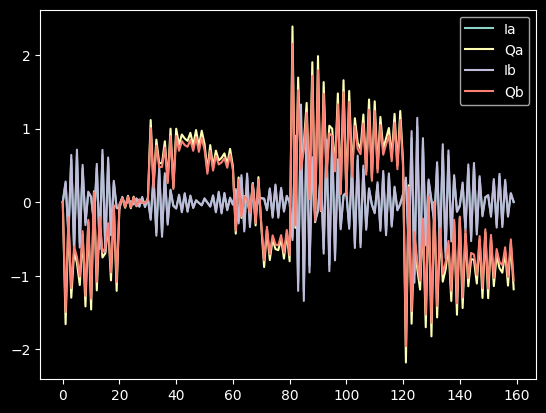

In [6]:
A[0].quadratures.plot()

In [7]:
import numpy as np
import sys

# Pour afficher TOUT le tableau sans troncature
np.set_printoptions(threshold=sys.maxsize)

# Pour afficher un nombre précis de chiffres après la virgule (ex: 4)
np.set_printoptions(precision=4, suppress=True)

print(A[0].quadratures.L_Ia.reshape(10, -1))

[[-0.      0.2557 -0.4237  0.5797 -0.6224  0.6428 -0.5536  0.4579 -0.2805
   0.1305  0.0647 -0.2726  0.4679 -0.5712  0.6397 -0.6081]
 [ 0.5474 -0.4057  0.2633 -0.0747 -0.0774  0.0611 -0.0402  0.0164  0.0072
  -0.0282  0.0451 -0.0559  0.0602 -0.0583  0.0504 -0.2175]
 [ 0.3198 -0.4127  0.4267 -0.4266  0.3532 -0.2793  0.1525 -0.0498 -0.0804
   0.0861 -0.1255  0.1063 -0.1211  0.0792 -0.0755  0.0216]
 [-0.0124 -0.0406  0.0423 -0.006  -0.0585  0.0821 -0.126   0.1236 -0.139
   0.1089 -0.1001  0.0518 -0.032   0.1599 -0.2618  0.33  ]
 [-0.3593  0.35   -0.3061  0.2339 -0.1435  0.0451  0.0507  0.0453 -0.0995
   0.1699 -0.1877  0.2151 -0.1886  0.1751 -0.1147  0.0775]
 [-0.0049 -0.474   0.823  -1.0987  1.2005 -1.2176  1.0669 -0.8641  0.5463
  -0.2403 -0.1108  0.381  -0.6374  0.7661 -0.8527  0.8031]
 [-0.7196  0.5265 -0.3379  0.0857  0.1133 -0.3297  0.453  -0.5657  0.5692
  -0.5583  0.4488 -0.3452  0.171  -0.0358 -0.1364  0.2389]
 [-0.3531  0.3797 -0.4096  0.3525 -0.3071  0.191  -0.1074 -0.0245  0.1

In [8]:
%matplotlib qt

ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

In [ ]:
A[0].photon_distribution.plot_joint_proba()

In [ ]:
A[0].photon_distribution.plot_marginal_proba(mode='a')

In [ ]:
A[0].photon_distribution.plot_marginal_proba(mode='b')

In [ ]:
A[0].photon_distribution.P_b[-1]

Pour un drive constant (sans effet Kerr et sans JRM) :

$$ \langle N_a \rangle \sim \dfrac{4\epsilon_a^2}{\kappa_a}   $$


Pour un drive constant + JRM (sans effet Kerr) :

$$ \langle N_a \rangle \sim \left[  \dfrac{\sqrt{\kappa_a} \epsilon_a + \dfrac{2 (g_\text{conv} + g_\text{sq}) \epsilon_b}{\sqrt{\kappa_b}} }{\dfrac{2(g_\text{conv} + g_\text{sq})^2}{\kappa_b} - \dfrac{\kappa_a}{2}}    \right]^2  $$
